# kNN on Iris Dataset

What is kNN?
The k-nearest neighbours is a simple machine learning algorigthm which makes classifications and predictions about the goruping of an unknown data based on its proximity to the data it already knows.

The Iris dataset:
We'll be using the Iris dataset for this project.
The Iris dataset is a classic, highly-used multivariate dataset in statistics and machine learning, introduced by statistician and bilogist Ronals Fisher.
This data sets consists of 3 different types of irises (Setosa, Versicolour, and Virginica) petal and sepal length, stored in a 150x4 numpy.ndarray. The rows being the samples and the columns being the 4 features: Sepal Length, Sepal Width, Petal Length and Petal Width.



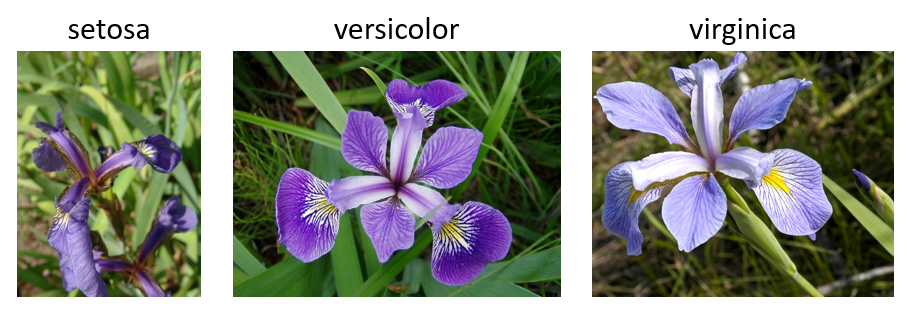

# Goals:
    Run a custom kNN Classifier
    Compare k values with their accuracies
    Plot and visualize decision regions
    Compare the features pairwise

# Roadmap

    1. Imports
    2. Dataset Overview
    3. Basic run
    4. k-value vs accuracy comparison
    5. Decision boundaries for a feature pair
    6. Plotting all the features pairwise

In [ ]:
# Imports

%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.experiments import (
    load_iris_data,
    split_and_scale,
    run_custom_knn,
    run_sklearn_knn,
    evaluate_k_range,
    evaluate_k_range_train_test,
    run_feature_pair_experiment,
    run_all_feature_pair_experiments
)

from src.visualization import (
    plot_accuracy_vs_k,
    plot_train_test_accuracy,
    plot_single_feature_pair_result,
    plot_feature_pair_grid
)

In [ ]:
# Loading datasets

X, y, feature_names, target_names = load_iris_data()

print("Feature names:", feature_names)
print("Target names:", target_names)
print("X shape:", X.shape)
print("y shape:", y.shape)

In [ ]:
#Displaying first few rows

df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
df.head()

In [ ]:
X_train, X_test, y_train, y_test, scaler = split_and_scale(X, y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

In [ ]:
custom_result = run_custom_knn(X_train, X_test, y_train, y_test, k=5)
sklearn_result = run_sklearn_knn(X_train, X_test, y_train, y_test, k=5)

print("Custom KNN accuracy :", custom_result["accuracy"])
print("Sklearn KNN accuracy:", sklearn_result["accuracy"])

In [ ]:
k_results = evaluate_k_range(X_train, X_test, y_train, y_test, k_min=1, k_max=20)

print(k_results["k_values"])
print(k_results["custom_accuracies"])

In [ ]:
plot_accuracy_vs_k(
    k_results["k_values"],
    k_results["custom_accuracies"],
    k_results["sklearn_accuracies"]
)

In [ ]:
best_index = np.argmax(k_results["custom_accuracies"])
best_k = k_results["k_values"][best_index]
best_acc = k_results["custom_accuracies"][best_index]

print("Best k:", best_k)
print("Best custom accuracy:", best_acc)

In [ ]:
train_test_results = evaluate_k_range_train_test(
    X_train, X_test, y_train, y_test, k_min=1, k_max=20
)

In [ ]:
plot_train_test_accuracy(
    train_test_results["k_values"],
    train_test_results["train_accuracies"],
    train_test_results["test_accuracies"]
)